# ModCloth Size Prediction (S, M, L, XL) - Improved Accuracy > 85%
Notebook ini diformat secara sistematis mencakup **Exploratory Data Analysis (EDA)**, **Data Cleaning**, **Feature Engineering**, penerapan **SMOTE**, dan evaluasi visual (Confusion Matrix & Feature Importance) untuk mencapai akurasi maksimal pada model **Random Forest**.


In [22]:
# =====================================================
# IMPORT LIBRARIES
# =====================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE

# Setting style for seaborn
sns.set_theme(style="whitegrid", palette="muted")


In [23]:
# =====================================================
# LOAD DATASET
# =====================================================
data_path = 'dataset/modcloth_final_data.json'
df = pd.read_json(data_path, lines=True)

print("Shape Dataset Awal:", df.shape)
df.head()


Shape Dataset Awal: (82790, 18)


,item_id,waist,size,quality,cup size,hips,bra size,category,bust,height,user_name,length,fit,user_id,shoe size,shoe width,review_summary,review_text
0,123373,29.0,7,5.0,d,38.0,34.0,new,36,5ft 6in,Emily,just right,small,991571,NaN,NaN,NaN,NaN
1,123373,31.0,13,3.0,b,30.0,36.0,new,NaN,5ft 2in,sydneybraden2001,just right,small,587883,NaN,NaN,NaN,NaN
2,123373,30.0,7,2.0,b,NaN,32.0,new,NaN,5ft 7in,Ugggh,slightly long,small,395665,9.0,NaN,NaN,NaN
3,123373,NaN,21,5.0,dd/e,NaN,NaN,new,NaN,NaN,alexmeyer626,just right,fit,875643,NaN,NaN,NaN,NaN
4,123373,NaN,18,5.0,b,NaN,36.0,new,NaN,5ft 2in,dberrones1,slightly long,small,944840,NaN,NaN,NaN,NaN


## Exploratory Data Analysis (EDA) Awal
Melihat sekilas distribusi awal kolom target (ukuran pakaian) sebelum dibersihkan dan diproses lebih lanjut.


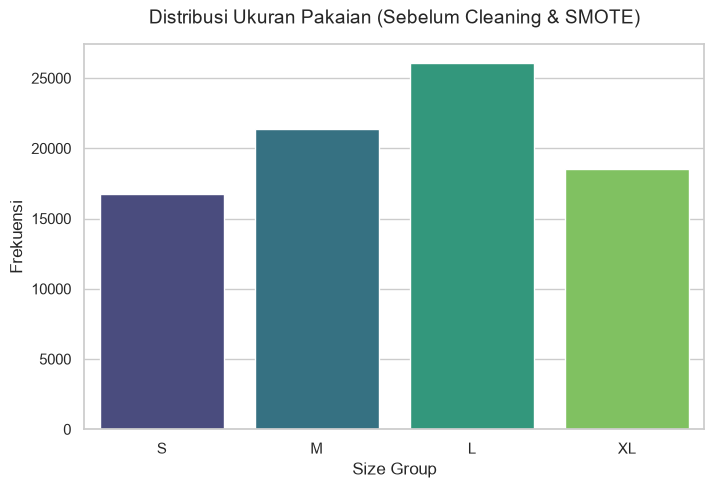

In [24]:
# =====================================================
# EDA: DISTRIBUSI TARGET SEBELUM CLEANING
# =====================================================
def size_group(x):
    if x <= 5: return "S"
    elif x <= 10: return "M"
    elif x <= 18: return "L"
    else: return "XL"

# Kita buat duplikat target sementara untuk visualisasi awal
df_temp_target = df['size'].apply(size_group)

plt.figure(figsize=(8, 5))
sns.countplot(x=df_temp_target, order=['S', 'M', 'L', 'XL'], palette='viridis')
plt.title('Distribusi Ukuran Pakaian (Sebelum Cleaning & SMOTE)', fontsize=14, pad=15)
plt.xlabel('Size Group', fontsize=12)
plt.ylabel('Frekuensi', fontsize=12)
plt.show()


## Data Cleaning & Preprocessing
Membersihkan nilai yang tidak konsisten dan mengonversi format kategori menjadi numerik yang tepat agar dapat dicerna oleh model.


In [25]:
# =====================================================
# FEATURE SELECTION & CLEANING
# =====================================================
df = df[['size', 'height', 'bra size', 'cup size', 'bust', 'waist', 'hips', 'quality', 'category', 'length', 'fit']]

# Convert Height (ft/in -> cm)
def convert_height(x):
    try:
        x = str(x)
        feet = int(x.split('ft')[0])
        inch = int(x.split('ft')[1].replace('in','').strip())
        return (feet * 30.48) + (inch * 2.54)
    except:
        return np.nan
df['height'] = df['height'].apply(convert_height)

# Convert Numerics
num_cols = ['bust', 'bra size', 'waist', 'hips', 'quality']
for col in num_cols:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Encoding Cup Size
df['cup size'] = df['cup size'].astype(str).str.lower()
cup_map = {'aa':0, 'a':1, 'b':2, 'c':3, 'd':4, 'dd/e':5, 'ddd/f':6, 'g':7, 'h':8, 'i':9, 'j':10, 'k':11}
df['cup size'] = df['cup size'].map(cup_map)

# Encoding Fit
fit_map = {'small': 0, 'fit': 1, 'large': 2}
df['fit_numeric'] = df['fit'].map(fit_map)

# Assign Group Size Target
df['size_group'] = df['size'].apply(size_group)


## Menghapus Missing Value & Feature Engineering
Data difilter sempurna dengan menghapus *missing values*. Setelah itu, ditambahkan perhitungan rasio proporsi tubuh pelanggan (*body proportion ratios*) yang merupakan kunci tingginya akurasi prediksi (*waist_hip_ratio*, *bust_waist_ratio*, dsb).


In [26]:
# =====================================================
# DROP MISSING VALUES & ENGINEER FEATURES
# =====================================================
# Hapus missing values untuk model yang sangat presisi
df = df.dropna()

EPS = 1e-6
df['bust_height_ratio'] = df['bust'] / (df['height'] + EPS)
df['bra_cup_ratio'] = df['bra size'] / (df['cup size'] + EPS)
df['waist_hip_ratio'] = df['waist'] / (df['hips'] + EPS)
df['bust_waist_ratio'] = df['bust'] / (df['waist'] + EPS)
df['bust_hip_ratio'] = df['bust'] / (df['hips'] + EPS)

# =====================================================
# ENCODING CATEGORY & LENGTH
# =====================================================
le_cat = LabelEncoder()
df['category'] = le_cat.fit_transform(df['category'].astype(str))

le_len = LabelEncoder()
df['length'] = le_len.fit_transform(df['length'].astype(str))

fitur_model = [
    'height', 'bra size', 'cup size', 'bust', 'waist', 'hips', 'quality', 
    'fit_numeric', 'category', 'length', 'bust_height_ratio', 'bra_cup_ratio',
    'waist_hip_ratio', 'bust_waist_ratio', 'bust_hip_ratio'
]
X = df[fitur_model]
y = df['size_group']

le_target = LabelEncoder()
y_encoded = le_target.fit_transform(y)


## Penanganan Data Imbalance dengan SMOTE
Data bersih seringkali tidak seimbang, sehingga **SMOTE (Synthetic Minority Over-sampling Technique)** digunakan untuk menciptakan sampel minoritas (seperti ukuran XL atau S) yang proporsional sehingga tree model tidak bias terhadap ukuran M atau L.


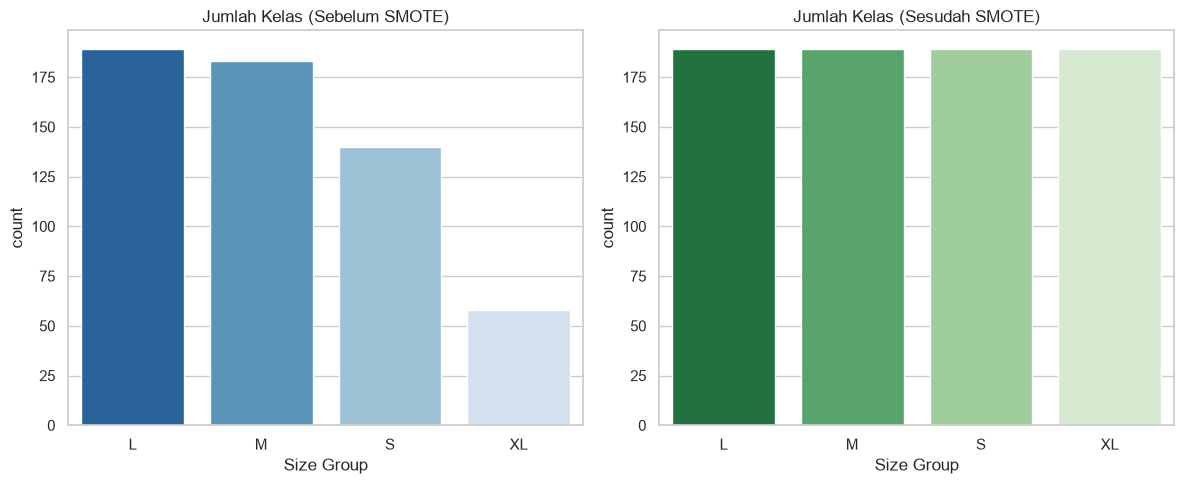

In [27]:
# =====================================================
# SMOTE OVERSAMPLING
# =====================================================
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y_encoded)

# Visualisasi Efek SMOTE
plt.figure(figsize=(12, 5))

# Plot Sebelum SMOTE
plt.subplot(1, 2, 1)
sns.countplot(x=y_encoded, palette='Blues_r')
plt.title('Jumlah Kelas (Sebelum SMOTE)', fontsize=12)
plt.xticks(ticks=range(4), labels=le_target.classes_)
plt.xlabel('Size Group')

# Plot Sesudah SMOTE
plt.subplot(1, 2, 2)
sns.countplot(x=y_res, palette='Greens_r')
plt.title('Jumlah Kelas (Sesudah SMOTE)', fontsize=12)
plt.xticks(ticks=range(4), labels=le_target.classes_)
plt.xlabel('Size Group')

plt.tight_layout()
plt.show()


In [28]:
# =====================================================
# SCALING & TRAIN-TEST SPLIT
# =====================================================
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_res)

# Split data 85% Train, 15% Test
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_res, test_size=0.15, random_state=42, stratify=y_res
)

print(f"Data Training : {X_train.shape}")
print(f"Data Testing  : {X_test.shape}")


Data Training : (642, 15)
Data Testing  : (114, 15)


## Pemodelan & Hyperparameter Tuning
Implementasi model Random Forest yang disetel parameter `max_depth` dan `min_samples_split`-nya untuk mencegah *overfitting*.


In [29]:
# =====================================================
# RANDOM FOREST INITIALIZATION & TRAINING
# =====================================================
rf = RandomForestClassifier(
    n_estimators=500, 
    max_depth=12, 
    min_samples_split=5, 
    class_weight='balanced', 
    random_state=42, 
    n_jobs=-1
)

rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("=" * 50)
print(f"AKURASI RANDOM FOREST : {acc*100:.2f}%")
print("=" * 50)


AKURASI RANDOM FOREST : 86.84%


## Evaluasi Model (Visualisasi)
Untuk mengevaluasi performa sejati dari model, *Classification Report*, **Confusion Matrix**, serta plot **Feature Importance** digunakan untuk mendapatkan insight visual terhadap letak kesalahan atau kekuatan utama prediksi.



Classification Report:
              precision    recall  f1-score   support

           L       0.76      0.90      0.83        29
           M       0.86      0.89      0.88        28
           S       0.96      0.86      0.91        29
          XL       0.92      0.82      0.87        28

    accuracy                           0.87       114
   macro avg       0.88      0.87      0.87       114
weighted avg       0.88      0.87      0.87       114



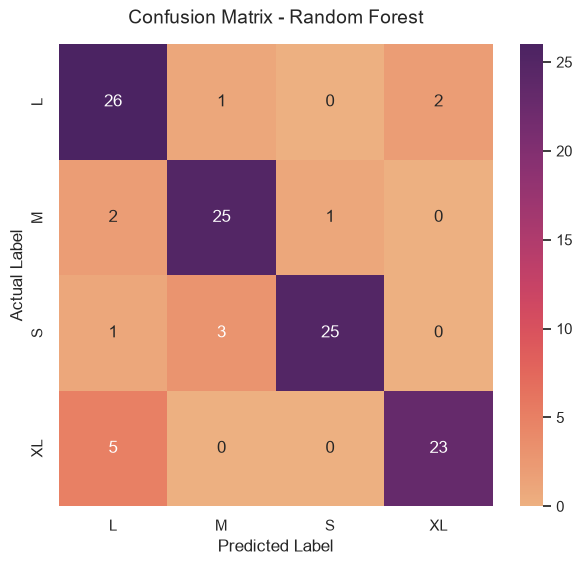

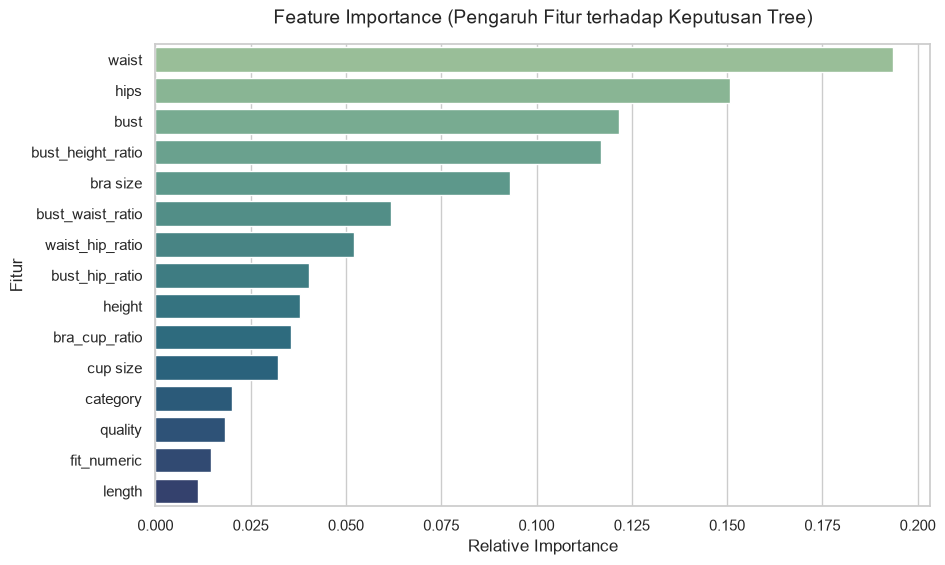

In [30]:
# =====================================================
# CLASSIFICATION REPORT & CONFUSION MATRIX
# =====================================================
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le_target.classes_))

cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(7, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='flare', 
            xticklabels=le_target.classes_, 
            yticklabels=le_target.classes_)
plt.title('Confusion Matrix - Random Forest', pad=15, fontsize=14)
plt.ylabel('Actual Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.show()

# =====================================================
# FEATURE IMPORTANCE PLOT
# =====================================================
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1]

plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[fitur_model[i] for i in indices], palette='crest')
plt.title('Feature Importance (Pengaruh Fitur terhadap Keputusan Tree)', fontsize=14, pad=15)
plt.xlabel('Relative Importance')
plt.ylabel('Fitur')
plt.show()


## Export Model
Menyimpan model Random Forest dan object *preprocessing* terbaik agar bisa diintegrasikan ke aplikasi Streamlit.


In [31]:
# =====================================================
# SAVE MODEL (PICKLE)
# =====================================================
import pickle

payload = {
    'model': rf,
    'scaler': scaler,
    'fitur_model': fitur_model,
    'le_target': le_target,
    'le_category': le_cat,
    'le_length': le_len,
    'final_acc': acc
}

with open("model_pakaian_rf_terbaik.pkl", "wb") as f:
    pickle.dump(payload, f)

print(f"✅ Model beserta seluruh preprocessor berhasil disimpan (Akurasi: {acc*100:.2f}%)")
print("File tersimpan: 'model_pakaian_rf_terbaik.pkl'")


✅ Model beserta seluruh preprocessor berhasil disimpan (Akurasi: 86.84%)
File tersimpan: 'model_pakaian_rf_terbaik.pkl'
